✅ All libraries imported successfully!
📂 Please upload 'StudentsPerformance.csv'


Saving StudentsPerformance.csv to StudentsPerformance.csv

📊 Dataset shape: (1000, 8)

First 5 rows:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75



Data types:
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

Missing values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Basic statistics:


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Grade distribution:
grade
C    391
B    272
D    231
F     54
A     52
Name: count, dtype: int64

Pass/Fail distribution:
pass_fail
1    715
0    285
Name: count, dtype: int64

✅ Feature matrix shape: (1000, 5)
Grade classes: ['A' 'B' 'C' 'D' 'F']
Train size: 800 | Test size: 200
Model                   Train Acc   Test Acc    CV Mean      MAE
KNN                        0.4713     0.2950     0.2838   0.9200
Random Forest              0.5525     0.2700     0.2800   0.9550
Gradient Boosting          0.5400     0.3100     0.2975   0.8650
AdaBoost                   0.4100     0.4050     0.3950   0.6850
Extra Trees                0.5525     0.2700     0.2938   0.9150


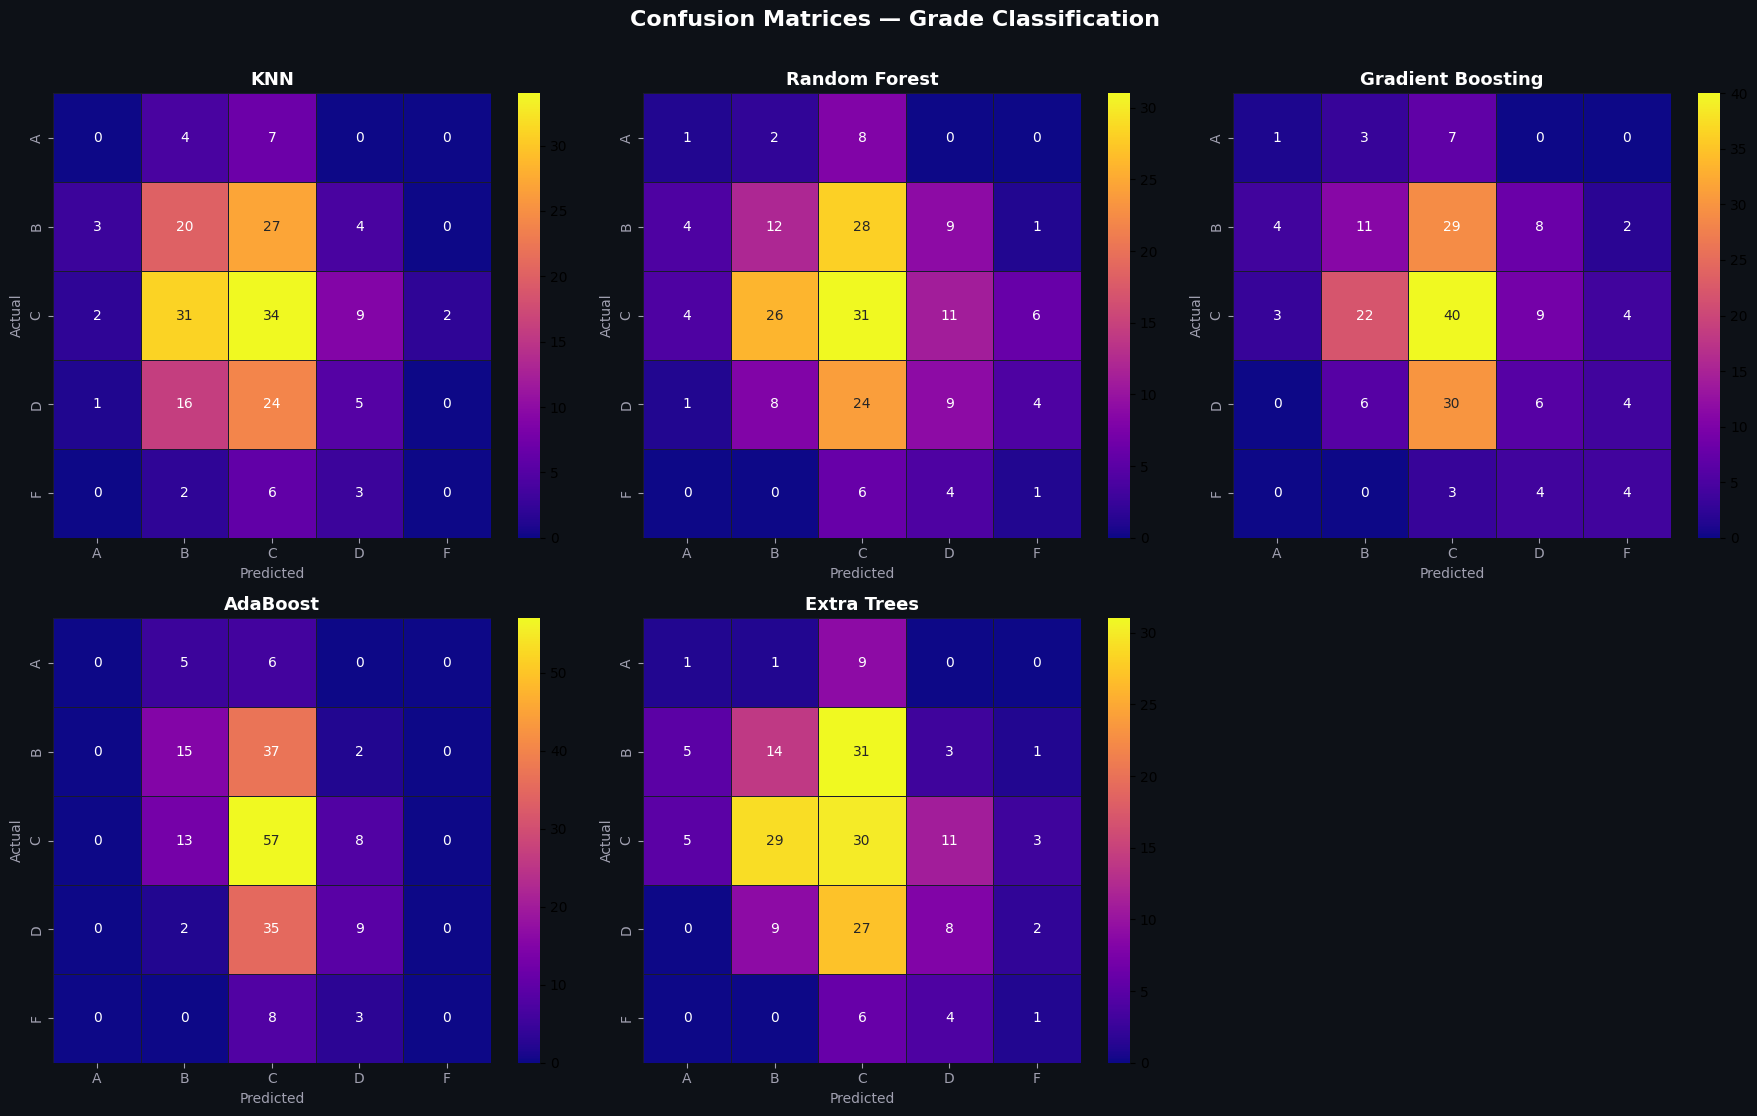

✅ Saved: confusion_matrices.png


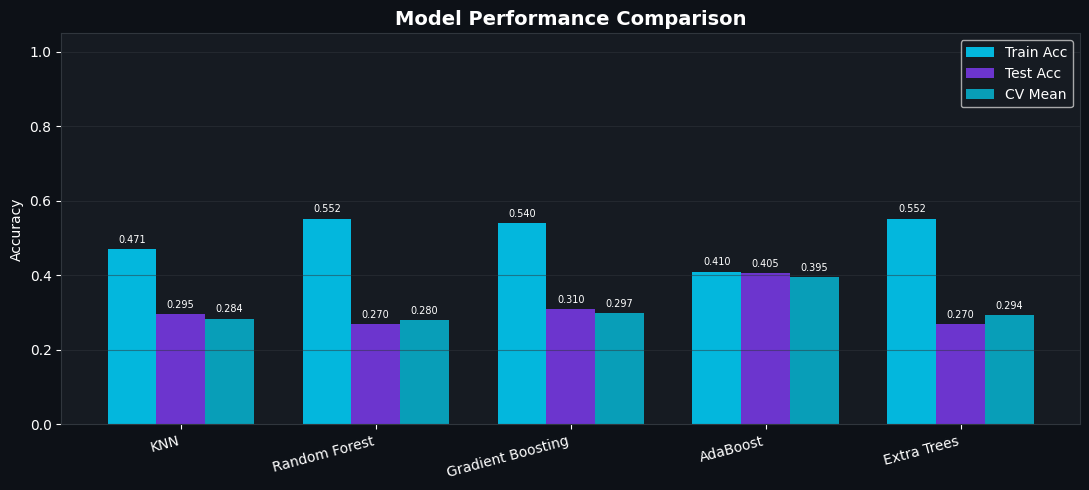

✅ Saved: model_comparison.png


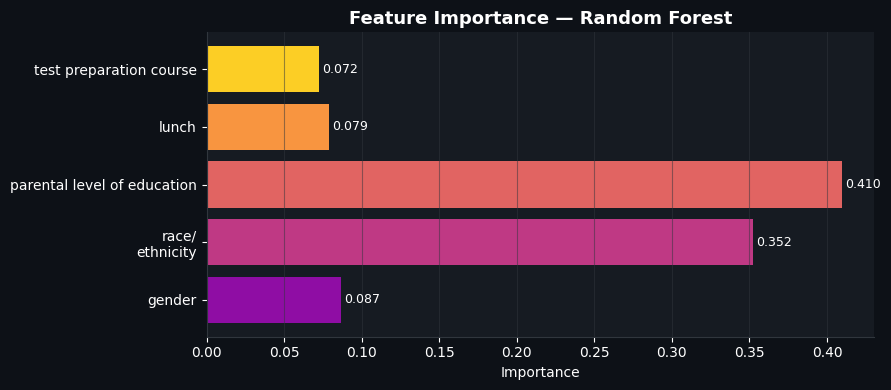

✅ Saved: feature_importance.png
✅ All models saved to 'student_models/' directory
{
  "KNN": {
    "train_acc": 0.4713,
    "test_acc": 0.295,
    "cv_mean": 0.2838,
    "cv_std": 0.0219,
    "mae": 0.92
  },
  "Random Forest": {
    "train_acc": 0.5525,
    "test_acc": 0.27,
    "cv_mean": 0.28,
    "cv_std": 0.0165,
    "mae": 0.955
  },
  "Gradient Boosting": {
    "train_acc": 0.54,
    "test_acc": 0.31,
    "cv_mean": 0.2975,
    "cv_std": 0.0211,
    "mae": 0.865
  },
  "AdaBoost": {
    "train_acc": 0.41,
    "test_acc": 0.405,
    "cv_mean": 0.395,
    "cv_std": 0.0394,
    "mae": 0.685
  },
  "Extra Trees": {
    "train_acc": 0.5525,
    "test_acc": 0.27,
    "cv_mean": 0.2938,
    "cv_std": 0.0277,
    "mae": 0.915
  }
}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started: student_models.zip

📌 NEXT STEPS:
   1. Unzip student_models.zip
   2. Place all .pkl + .json files alongside app.py
   3. Run: python app.py


In [1]:
# ============================================================
# Student Performance Prediction — Google Colab Training Script
# Models: KNN, Random Forest, Gradient Boosting, AdaBoost, Extra Trees
# ============================================================

# ── CELL 1: Install & Imports ──────────────────────────────
!pip install -q scikit-learn pandas numpy matplotlib seaborn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, json, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, mean_absolute_error, r2_score)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              AdaBoostClassifier, ExtraTreesClassifier)

print("✅ All libraries imported successfully!")

# ── CELL 2: Load & Explore Dataset ────────────────────────
# Upload the CSV from your local machine (Colab will prompt)
from google.colab import files
print("📂 Please upload 'StudentsPerformance.csv'")
uploaded = files.upload()

df = pd.read_csv('StudentsPerformance.csv')
print(f"\n📊 Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic statistics:")
display(df.describe())

# ── CELL 3: Feature Engineering & Preprocessing ───────────
# Create average score (regression target) and pass/fail (classification target)
df['avg_score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3

# Grade classification: A(≥90), B(≥75), C(≥60), D(≥45), F(<45)
def assign_grade(avg):
    if avg >= 90: return 'A'
    elif avg >= 75: return 'B'
    elif avg >= 60: return 'C'
    elif avg >= 45: return 'D'
    else: return 'F'

df['grade'] = df['avg_score'].apply(assign_grade)
df['pass_fail'] = (df['avg_score'] >= 60).astype(int)  # 1=Pass, 0=Fail

print("Grade distribution:")
print(df['grade'].value_counts())
print("\nPass/Fail distribution:")
print(df['pass_fail'].value_counts())

# ── CELL 4: Encode Categorical Features ───────────────────
le = LabelEncoder()
cat_cols = ['gender', 'race/ethnicity', 'parental level of education',
            'lunch', 'test preparation course']

df_encoded = df.copy()
encoders = {}
for col in cat_cols:
    le_col = LabelEncoder()
    df_encoded[col + '_enc'] = le_col.fit_transform(df[col])
    encoders[col] = le_col

# Encode target label
le_grade = LabelEncoder()
df_encoded['grade_enc'] = le_grade.fit_transform(df['grade'])

feature_cols = [c + '_enc' for c in cat_cols]
X = df_encoded[feature_cols].values

# Two targets
y_grade = df_encoded['grade_enc'].values        # multiclass (A-F)
y_pass  = df_encoded['pass_fail'].values         # binary

print(f"\n✅ Feature matrix shape: {X.shape}")
print(f"Grade classes: {le_grade.classes_}")

# ── CELL 5: Train/Test Split & Scaling ────────────────────
X_train, X_test, yg_train, yg_test = train_test_split(
    X, y_grade, test_size=0.2, random_state=42, stratify=y_grade)
_, _, yp_train, yp_test = train_test_split(
    X, y_pass, test_size=0.2, random_state=42, stratify=y_pass)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

# ── CELL 6: Define Models ──────────────────────────────────
models = {
    'KNN': KNeighborsClassifier(n_neighbors=7, metric='minkowski'),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10,
                                            random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                                     max_depth=4, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=150, learning_rate=0.5, random_state=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=200, max_depth=10,
                                        random_state=42, n_jobs=-1),
}

# ── CELL 7: Train & Evaluate All Models ───────────────────
results = {}

print("=" * 65)
print(f"{'Model':<22} {'Train Acc':>10} {'Test Acc':>10} {'CV Mean':>10} {'MAE':>8}")
print("=" * 65)

for name, model in models.items():
    # KNN needs scaled data
    Xtr = X_train_sc if name == 'KNN' else X_train
    Xte = X_test_sc  if name == 'KNN' else X_test

    model.fit(Xtr, yg_train)
    y_pred = model.predict(Xte)

    train_acc = accuracy_score(yg_train, model.predict(Xtr))
    test_acc  = accuracy_score(yg_test,  y_pred)
    cv_scores = cross_val_score(model, Xtr, yg_train, cv=5, scoring='accuracy')
    mae       = mean_absolute_error(yg_test, y_pred)

    results[name] = {
        'model': model,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'mae': mae,
        'y_pred': y_pred,
        'report': classification_report(yg_test, y_pred,
                                        target_names=le_grade.classes_,
                                        output_dict=True)
    }

    print(f"{name:<22} {train_acc:>10.4f} {test_acc:>10.4f} "
          f"{cv_scores.mean():>10.4f} {mae:>8.4f}")

print("=" * 65)

# ── CELL 8: Confusion Matrices ────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
fig.patch.set_facecolor('#0d1117')

for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(yg_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='plasma',
                xticklabels=le_grade.classes_,
                yticklabels=le_grade.classes_,
                ax=axes[idx],
                linewidths=0.5, linecolor='#1a1a2e')
    axes[idx].set_title(name, color='white', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Predicted', color='#a0a0b0')
    axes[idx].set_ylabel('Actual', color='#a0a0b0')
    axes[idx].tick_params(colors='#a0a0b0')

axes[5].set_visible(False)
plt.suptitle('Confusion Matrices — Grade Classification',
             color='white', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print("✅ Saved: confusion_matrices.png")

# ── CELL 9: Model Comparison Bar Chart ────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

names  = list(results.keys())
t_acc  = [results[n]['train_acc'] for n in names]
te_acc = [results[n]['test_acc']  for n in names]
cv_m   = [results[n]['cv_mean']   for n in names]

x = np.arange(len(names))
w = 0.25
colors = ['#00d4ff', '#7c3aed', '#06b6d4']

bars1 = ax.bar(x - w, t_acc,  w, label='Train Acc',  color=colors[0], alpha=0.85)
bars2 = ax.bar(x,     te_acc, w, label='Test Acc',   color=colors[1], alpha=0.85)
bars3 = ax.bar(x + w, cv_m,   w, label='CV Mean',    color=colors[2], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right', color='white')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy', color='white')
ax.set_title('Model Performance Comparison', color='white', fontsize=14, fontweight='bold')
ax.tick_params(colors='white')
ax.spines[['top','right','left','bottom']].set_color('#30363d')
ax.yaxis.set_tick_params(color='white')
ax.legend(facecolor='#161b22', labelcolor='white')
ax.grid(axis='y', color='#30363d', alpha=0.5)

for bar in [*bars1, *bars2, *bars3]:
    h = bar.get_height()
    ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', color='white', fontsize=7)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print("✅ Saved: model_comparison.png")

# ── CELL 10: Feature Importance (Random Forest) ───────────
rf_model = results['Random Forest']['model']
importances = rf_model.feature_importances_
feat_names  = [c.replace('_enc', '').replace('/', '/\n') for c in feature_cols]

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

colors_bar = plt.cm.plasma(np.linspace(0.3, 0.9, len(feat_names)))
bars = ax.barh(feat_names, importances, color=colors_bar)
ax.set_xlabel('Importance', color='white')
ax.set_title('Feature Importance — Random Forest', color='white',
             fontsize=13, fontweight='bold')
ax.tick_params(colors='white')
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#30363d')
ax.grid(axis='x', color='#30363d', alpha=0.5)

for bar, val in zip(bars, importances):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', color='white', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print("✅ Saved: feature_importance.png")

# ── CELL 11: Save Models & Metadata ───────────────────────
os.makedirs('student_models', exist_ok=True)

# Save each model
for name, res in results.items():
    fname = name.lower().replace(' ', '_')
    joblib.dump(res['model'], f'student_models/{fname}_model.pkl')

# Save scaler, encoders, label encoder for grade
joblib.dump(scaler,    'student_models/scaler.pkl')
joblib.dump(encoders,  'student_models/encoders.pkl')
joblib.dump(le_grade,  'student_models/label_encoder_grade.pkl')

# Save metadata JSON (for Flask backend)
meta = {}
for name, res in results.items():
    meta[name] = {
        'train_acc': round(res['train_acc'], 4),
        'test_acc':  round(res['test_acc'],  4),
        'cv_mean':   round(res['cv_mean'],   4),
        'cv_std':    round(res['cv_std'],    4),
        'mae':       round(res['mae'],       4),
    }

with open('student_models/model_metrics.json', 'w') as f:
    json.dump(meta, f, indent=2)

print("✅ All models saved to 'student_models/' directory")
print(json.dumps(meta, indent=2))

# ── CELL 12: Download All Files ───────────────────────────
import zipfile
with zipfile.ZipFile('student_models.zip', 'w') as zf:
    for root, _, fnames in os.walk('student_models'):
        for fn in fnames:
            zf.write(os.path.join(root, fn))
    for img in ['confusion_matrices.png', 'model_comparison.png', 'feature_importance.png']:
        if os.path.exists(img):
            zf.write(img)

files.download('student_models.zip')
print("✅ Download started: student_models.zip")
print("\n📌 NEXT STEPS:")
print("   1. Unzip student_models.zip")
print("   2. Place all .pkl + .json files alongside app.py")
print("   3. Run: python app.py")